Matches Dataset:

       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision 

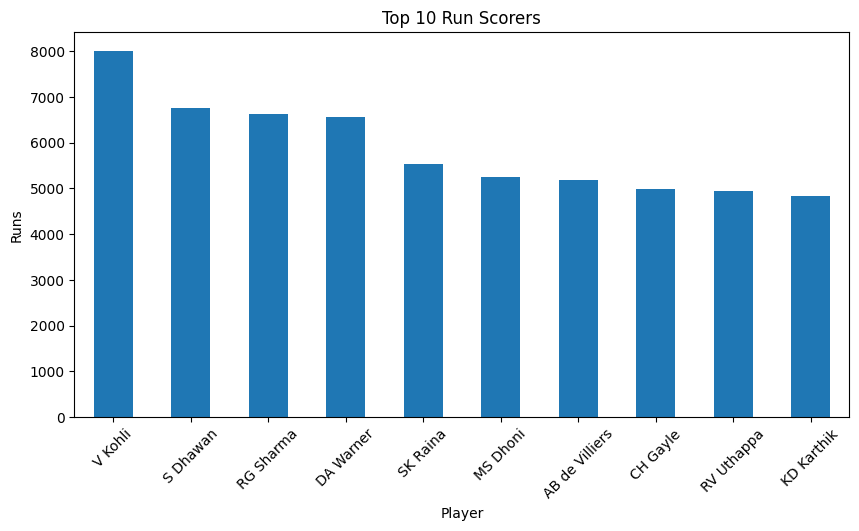


Top Strike Rates:

batter
L Wood             300.000000
B Stanlake         250.000000
J Fraser-McGurk    220.000000
R Sai Kishore      216.666667
Umar Gul           205.263158
RS Sodhi           200.000000
Shahid Afridi      176.086957
I Malhotra         175.000000
WG Jacks           172.932331
PD Salt            169.610390
dtype: float64


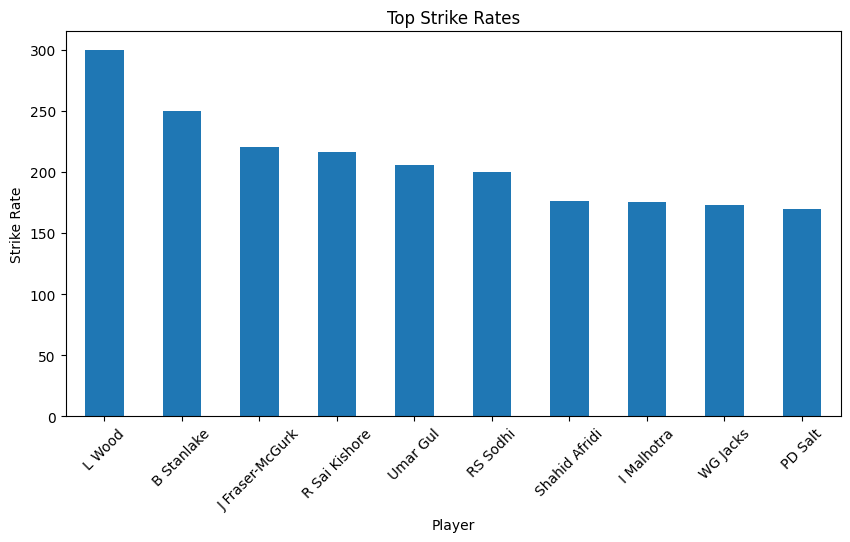


Team Win Rates:

Rising Pune Supergiant         62.500000
Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Delhi Capitals                 52.747253
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Sunrisers Hyderabad            48.351648
Royal Challengers Bangalore    48.333333
Royal Challengers Bengaluru    46.666667
Kings XI Punjab                46.315789
Gujarat Lions                  43.333333
Punjab Kings                   42.857143
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
Name: count, dtype: float64


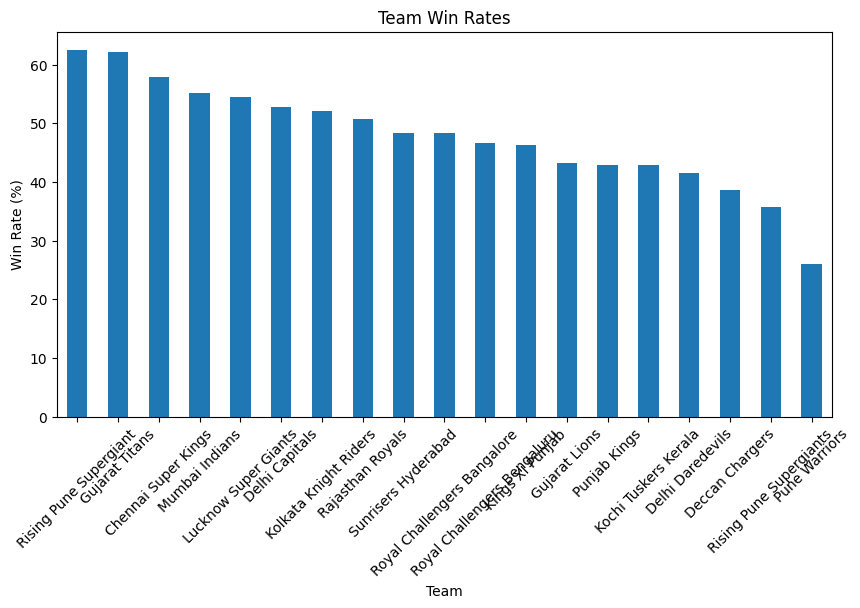

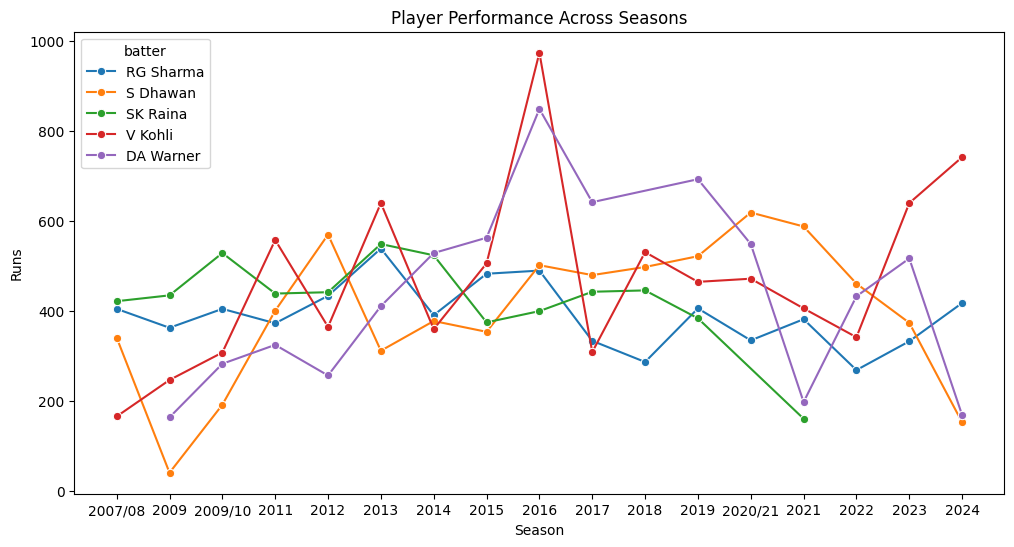

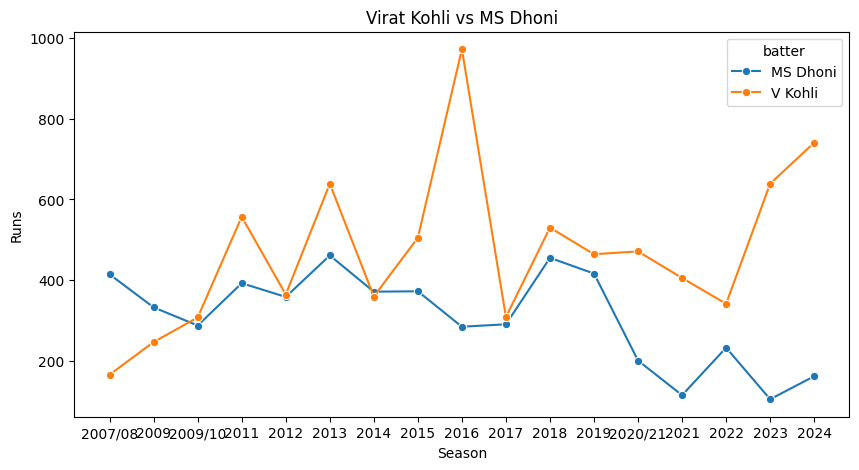


Summary exported as cricket_summary.csv

 Key Insights 
1. Certain players consistently dominate scoring across IPL seasons.
2. Strike rate analysis helps identify aggressive and efficient batsmen.
3. Teams with higher win rates demonstrate stronger overall consistency.
4. Player performances fluctuate across seasons based on form and experience.
5. Comparing players across seasons highlights long-term performance trends.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load Datasets


matches = pd.read_csv("/content/drive/MyDrive/matches.csv")
deliveries = pd.read_csv("/content/drive/MyDrive/deliveries.csv")

print("Matches Dataset:\n")
print(matches.head())

print("\nDeliveries Dataset:\n")
print(deliveries.head())


# 2. Top Scorers


top_scorers = deliveries.groupby('batter')['batsman_runs'].sum()

top_scorers = top_scorers.sort_values(ascending=False)

print("\nTop 10 Scorers:\n")
print(top_scorers.head(10))

# Visualization
plt.figure(figsize=(10,5))
top_scorers.head(10).plot(kind='bar')
plt.title("Top 10 Run Scorers")
plt.xlabel("Player")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.show()


# 3. Strike Rate Analysis


balls_faced = deliveries.groupby('batter')['ball'].count()

runs_scored = deliveries.groupby('batter')['batsman_runs'].sum()

strike_rate = (runs_scored / balls_faced) * 100

strike_rate = strike_rate.sort_values(ascending=False)

print("\nTop Strike Rates:\n")
print(strike_rate.head(10))

# Visualization
plt.figure(figsize=(10,5))
strike_rate.head(10).plot(kind='bar')
plt.title("Top Strike Rates")
plt.xlabel("Player")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45)
plt.show()


# 4. Team Win Rates


matches_played = pd.concat([matches['team1'], matches['team2']]).value_counts()

matches_won = matches['winner'].value_counts()

win_rate = (matches_won / matches_played) * 100

win_rate = win_rate.sort_values(ascending=False)

print("\nTeam Win Rates:\n")
print(win_rate)

# Visualization
plt.figure(figsize=(10,5))
win_rate.plot(kind='bar')
plt.title("Team Win Rates")
plt.xlabel("Team")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.show()


# 5. Per Season Runs


season_runs = deliveries.merge(
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)

season_player_runs = season_runs.groupby(
    ['season', 'batter']
)['batsman_runs'].sum().reset_index()

# Select top players only
top_players = top_scorers.head(5).index

filtered = season_player_runs[
    season_player_runs['batter'].isin(top_players)
]

# Visualization
plt.figure(figsize=(12,6))

sns.lineplot(
    data=filtered,
    x='season',
    y='batsman_runs',
    hue='batter',
    marker='o'
)

plt.title("Player Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.show()


# 6. Compare Specific Players


players_to_compare = ['V Kohli', 'MS Dhoni']

comparison = season_player_runs[
    season_player_runs['batter'].isin(players_to_compare)
]

# Visualization
plt.figure(figsize=(10,5))

sns.lineplot(
    data=comparison,
    x='season',
    y='batsman_runs',
    hue='batter',
    marker='o'
)

plt.title("Virat Kohli vs MS Dhoni")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.show()


# 7. Export Summary


summary = pd.DataFrame({
    'TopScorers': top_scorers.head(10),
    'StrikeRate': strike_rate.head(10)
})

summary.to_csv("cricket_summary.csv")

print("\nSummary exported as cricket_summary.csv")


# 8. Final Insights


print("\n Key Insights ")

print("1. Certain players consistently dominate scoring across IPL seasons.")

print("2. Strike rate analysis helps identify aggressive and efficient batsmen.")

print("3. Teams with higher win rates demonstrate stronger overall consistency.")

print("4. Player performances fluctuate across seasons based on form and experience.")

print("5. Comparing players across seasons highlights long-term performance trends.")